Loaded files:
metadata: (7, 2)
axes_df: (50, 3)
pulse_df: (93, 2)
long df: (4650, 19)

Metadata:


,field,value
0,frequency_Hz,7.893595e+09
1,nSigmaTrunc,2.000000e+00
2,conversion,-1.800000e+01
3,att0,1.400000e+01
4,n_times,1.030000e+02
5,n_attenuation,5.000000e+01
6,n_pulseSigmas,9.300000e+01



Axes preview:


,attenuation_index,attenuation,ampIf
0,0,7.000000,0.447744
1,1,7.168927,0.439120
2,2,7.341204,0.430497
3,3,7.516968,0.421873
4,4,7.696362,0.413249



Pulse sigma preview:


,pulse_index,pulseSigma_s
0,0,2.000000e-08
1,1,2.250000e-08
2,2,2.500000e-08
3,3,2.750000e-08
4,4,3.000000e-08



Long dataframe preview:


,pulse_index,pulseSigma_s,attenuation_index,attenuation,ampIf,I1,Q1,P1,I2,Q2,P2,PCorr,STD_I1,STD_Q1,STD_P1,STD_I2,STD_Q2,STD_P2,STD_PCorr
0,0,2.000000e-08,0,7.000000,0.447744,0.000867,0.003575,0.001124,0.001193,0.003283,0.001663,0.000040,0.000092,0.000092,0.000004,0.000113,0.000112,0.000007,0.000004
1,0,2.000000e-08,1,7.168927,0.439120,0.000924,0.003521,0.001129,0.000913,0.003284,0.001672,0.000043,0.000093,0.000092,0.000004,0.000113,0.000112,0.000007,0.000004
2,0,2.000000e-08,2,7.341204,0.430497,0.000865,0.003836,0.001142,0.000832,0.003374,0.001682,0.000052,0.000093,0.000093,0.000004,0.000113,0.000113,0.000007,0.000004
3,0,2.000000e-08,3,7.516968,0.421873,0.000838,0.003620,0.001136,0.001021,0.003007,0.001688,0.000055,0.000093,0.000092,0.000004,0.000113,0.000113,0.000007,0.000004
4,0,2.000000e-08,4,7.696362,0.413249,0.000864,0.003706,0.001150,0.000929,0.003211,0.001702,0.000058,0.000093,0.000093,0.000004,0.000114,0.000114,0.000007,0.000004



Unique pulse sigma count: 93
Unique attenuation count: 50

Pivot shape: (93, 50)

Best operating point based on PCorr:
pulseSigma_s = 2.000000e-08 s
attenuation = 10.957530276671385
ampIf = 0.2838922140386086
PCorr = 0.0001097882864099
STD_PCorr = 3.990884705019151e-06
Saved: figures\fig1_pcorr_heatmap.png


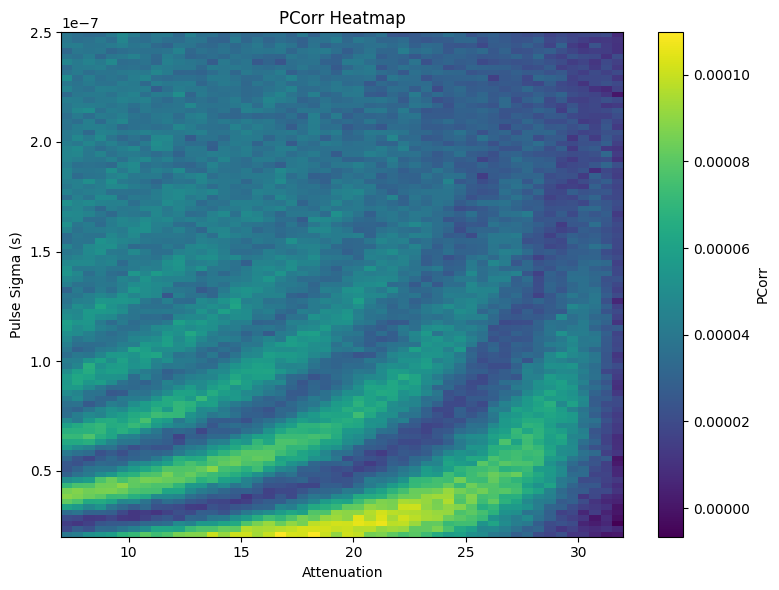

Saved: figures\fig2_p1_heatmap.png


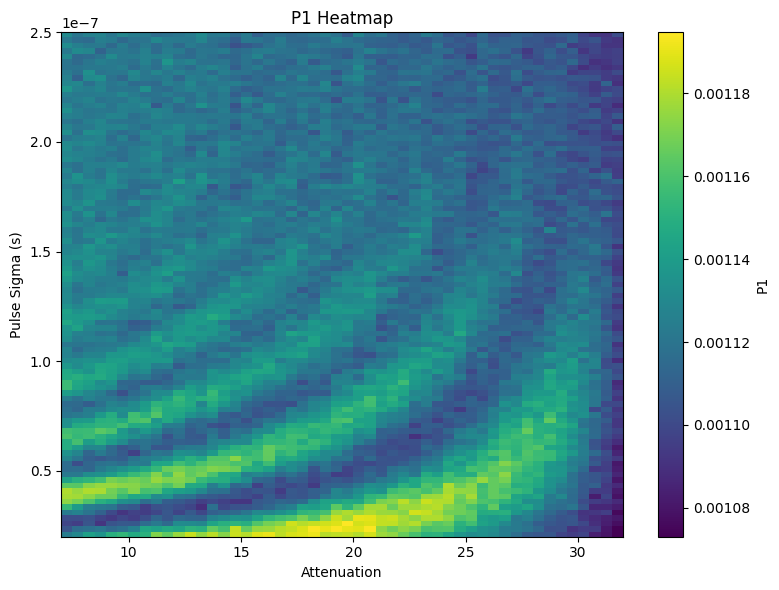

Saved: figures\fig3_p2_heatmap.png


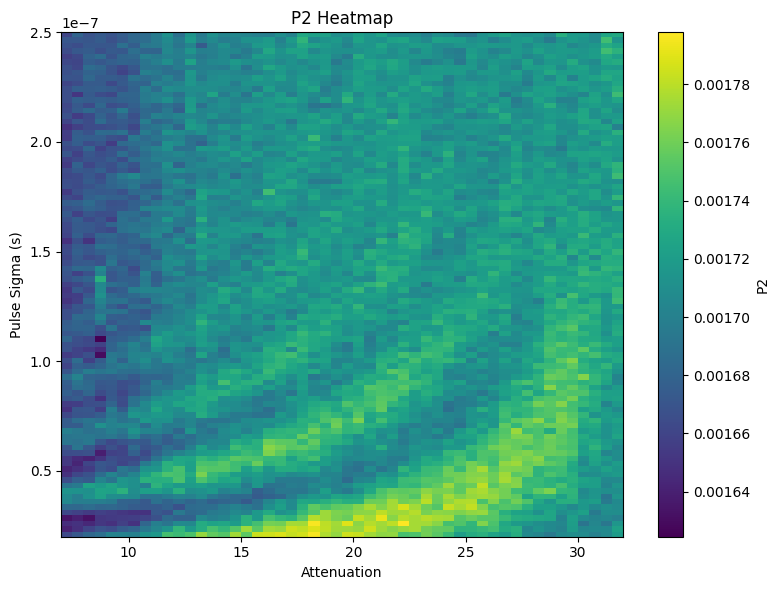

Saved: figures\fig4_i1_heatmap.png


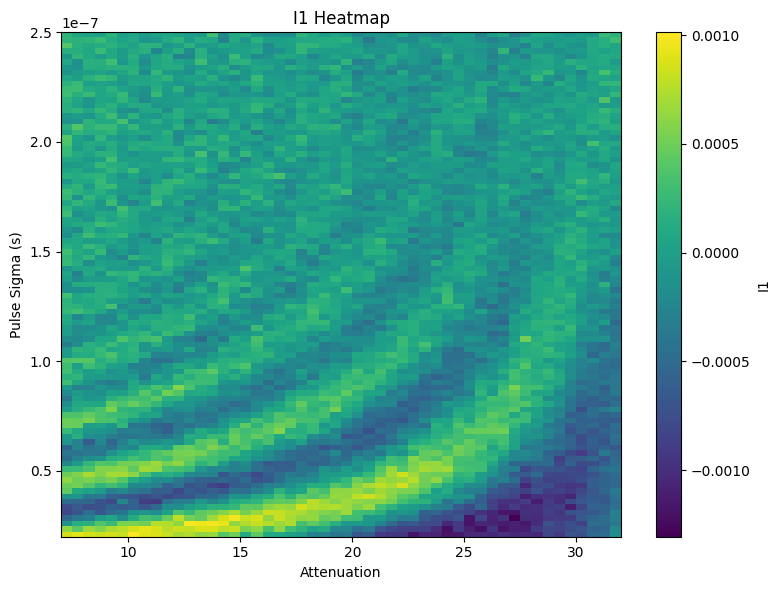

Saved: figures\fig5_q1_heatmap.png


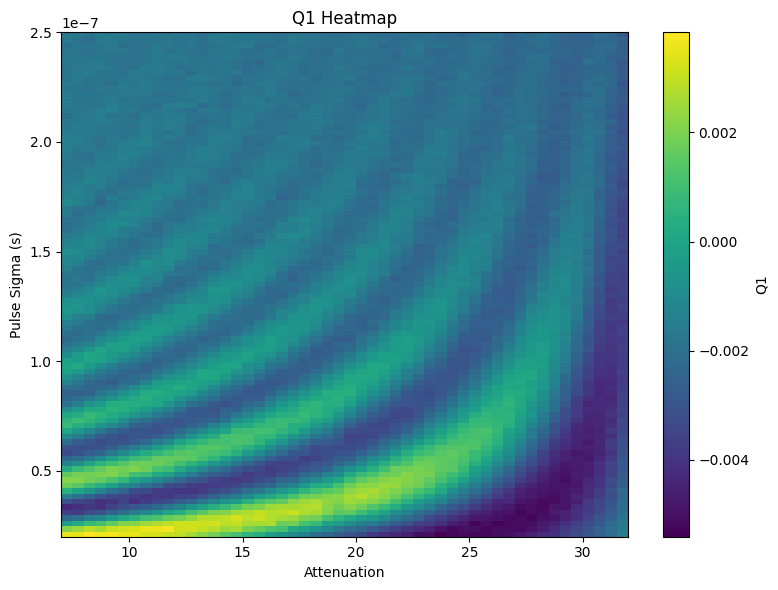

Saved: figures\fig6_i2_heatmap.png


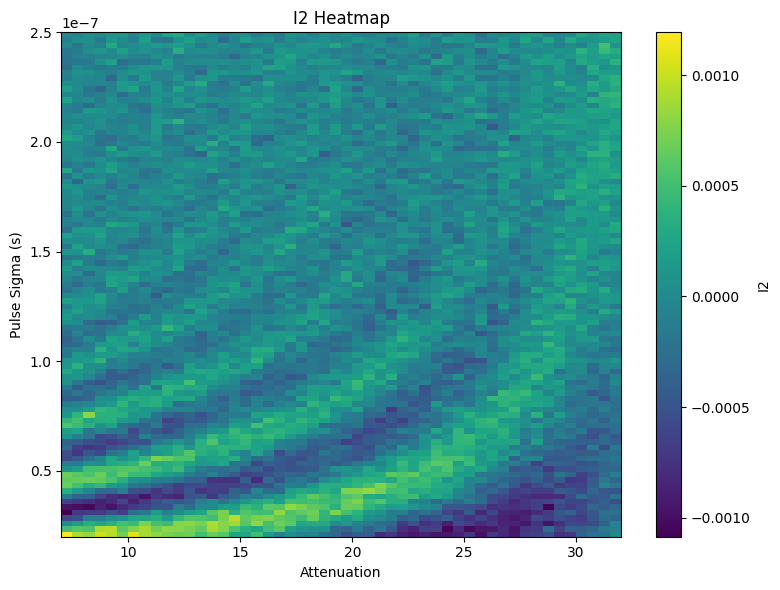

Saved: figures\fig7_q2_heatmap.png


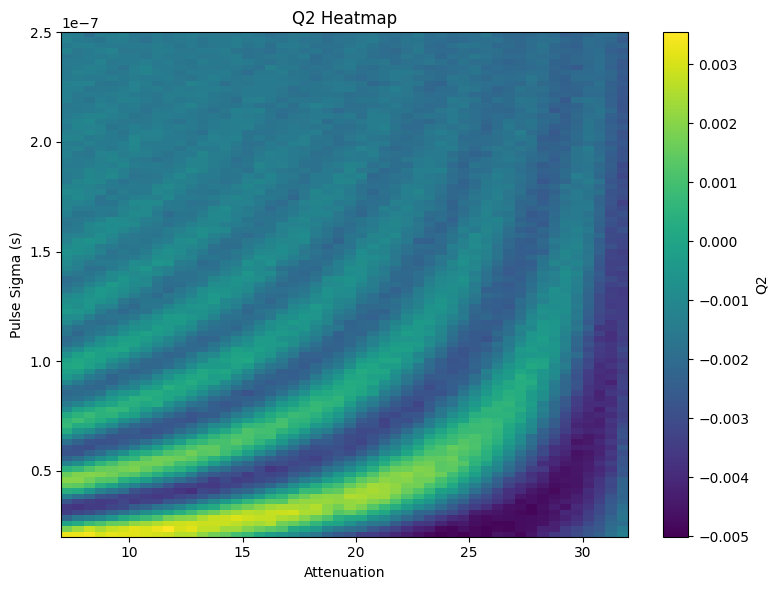

Saved: figures\fig8_std_pcorr_heatmap.png


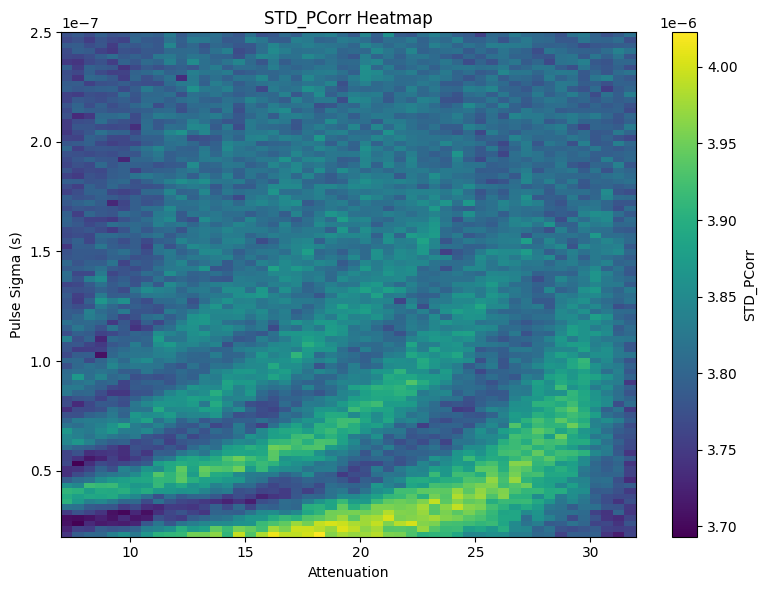

Saved: figures\fig9_best_pcorr_vs_pulsesigma.png


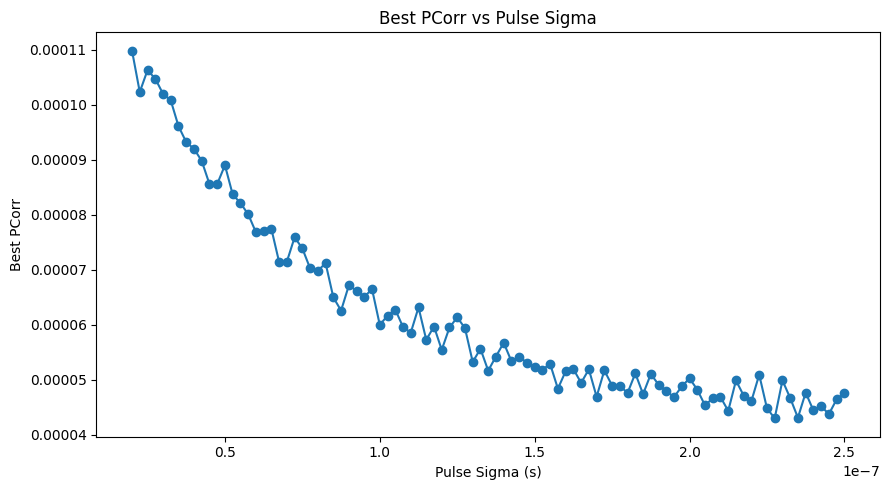

Saved: figures\fig10_best_attenuation_vs_pulsesigma.png


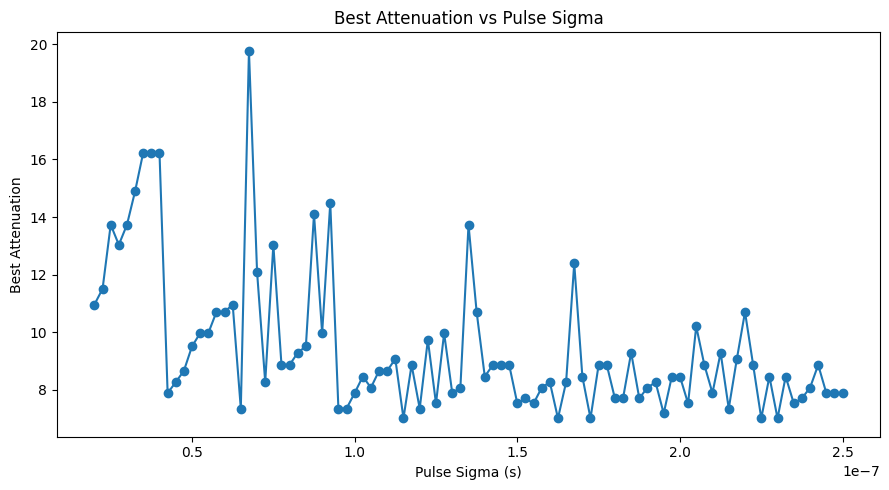

Saved: figures\fig11_best_ampif_vs_pulsesigma.png


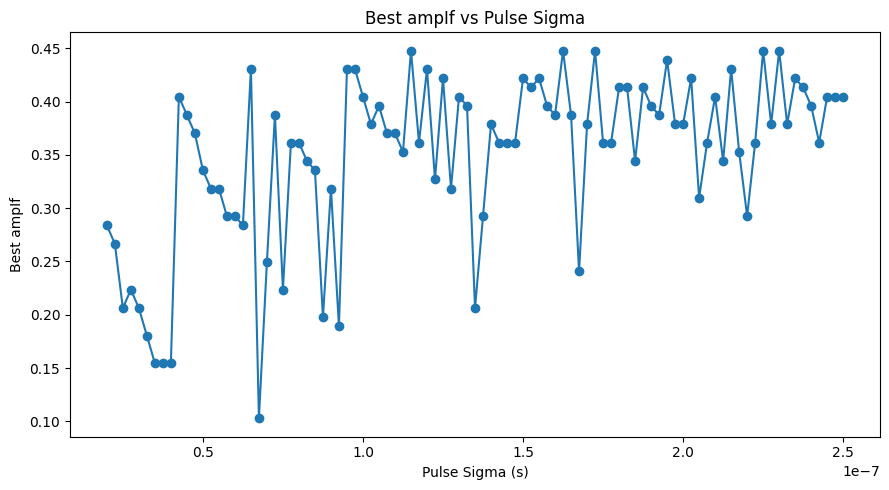

Saved: figures\fig12_pcorr_linecuts_selected_sigma.png


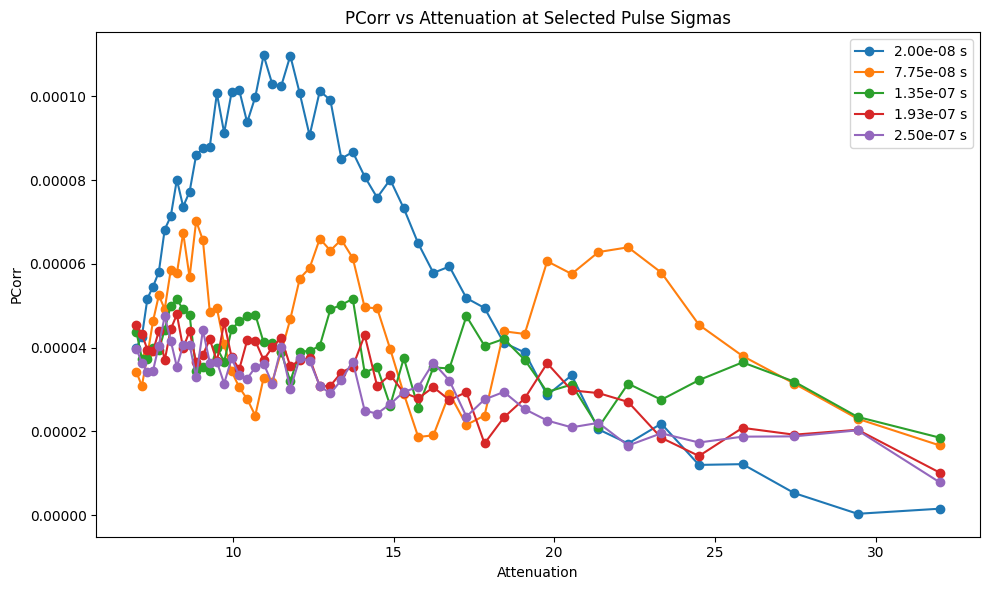

Saved: figures\fig13_pcorr_linecuts_selected_attenuation.png


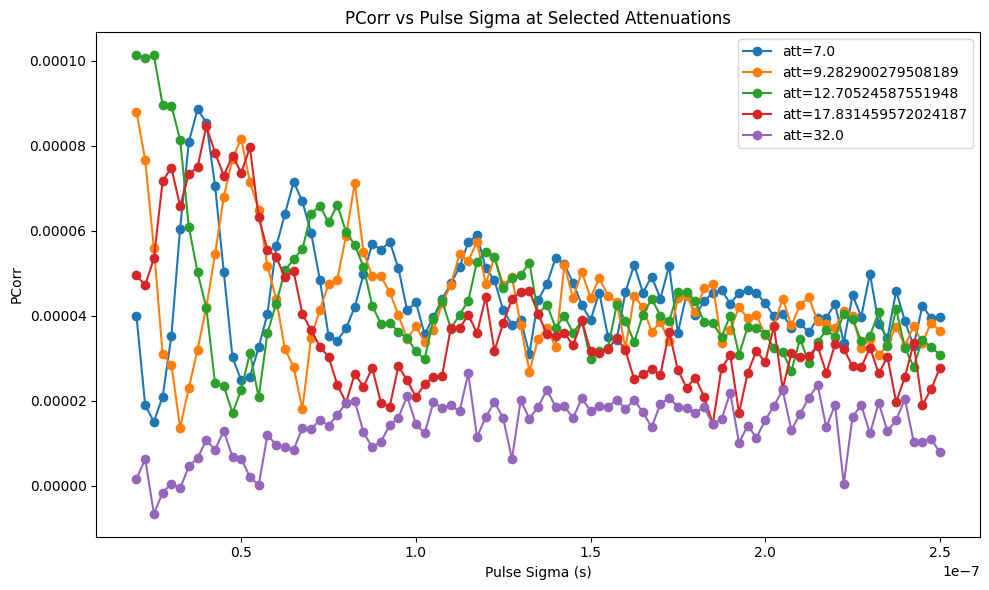

Saved: figures\fig14_best_pcorr_with_errorbars.png


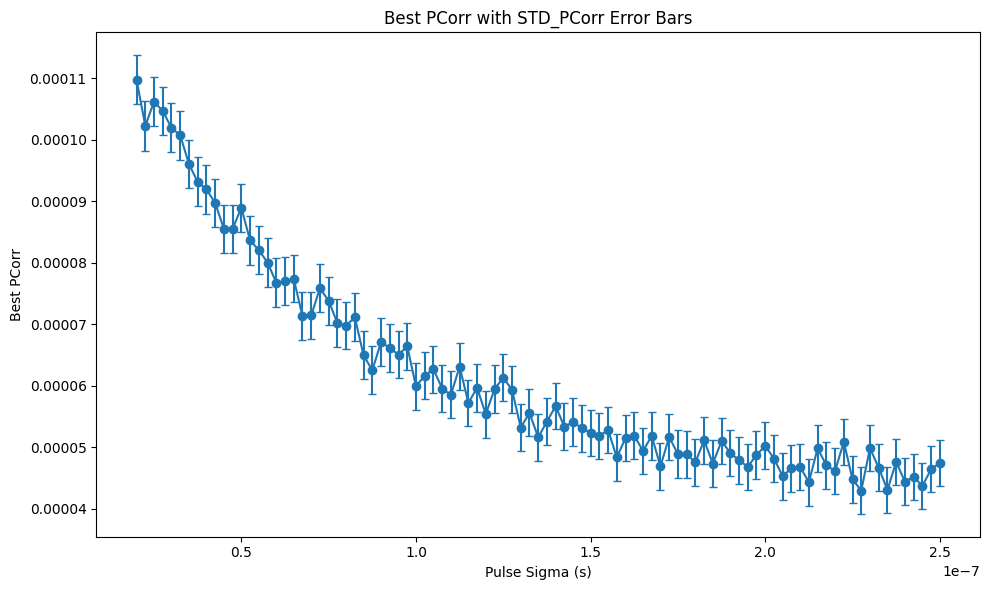

Saved: figures\fig15_i1_vs_q1_scatter.png


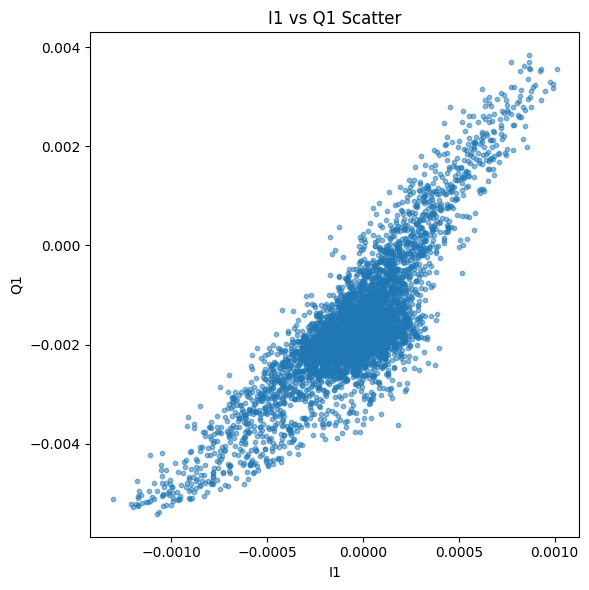

Saved: figures\fig16_i2_vs_q2_scatter.png


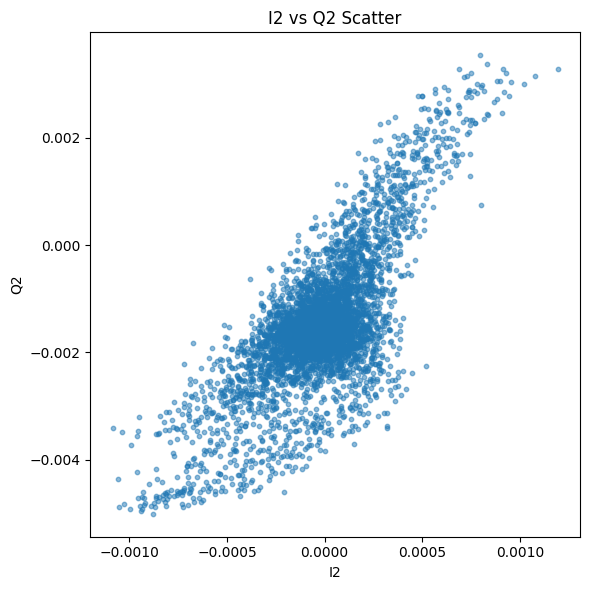

Saved: figures\fig17_p1_vs_p2_scatter.png


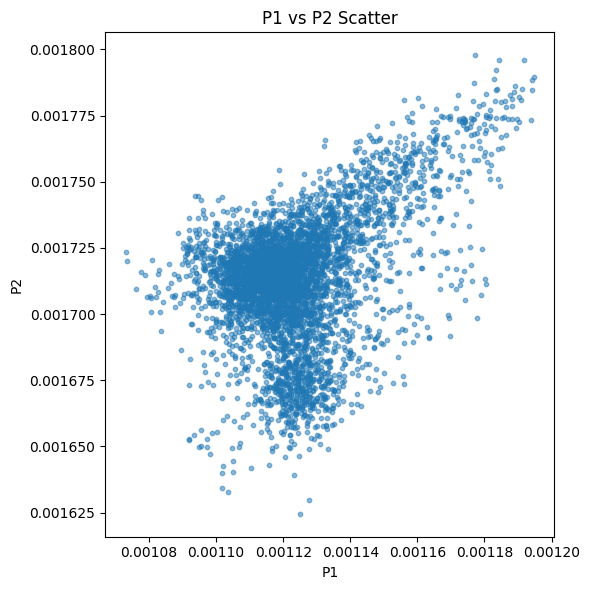

Saved: figures\fig18_hist_pcorr_p1_p2.png


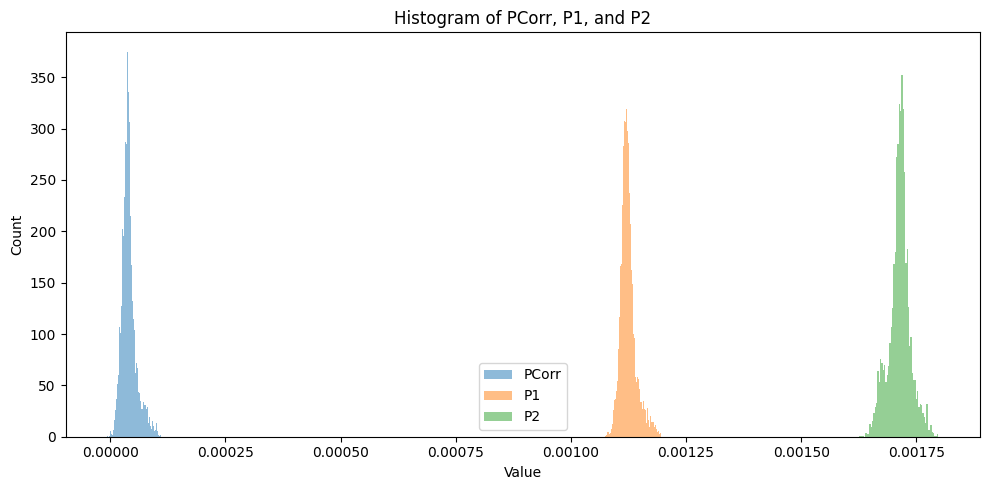

Saved: figures\fig19_mean_pcorr_vs_attenuation.png


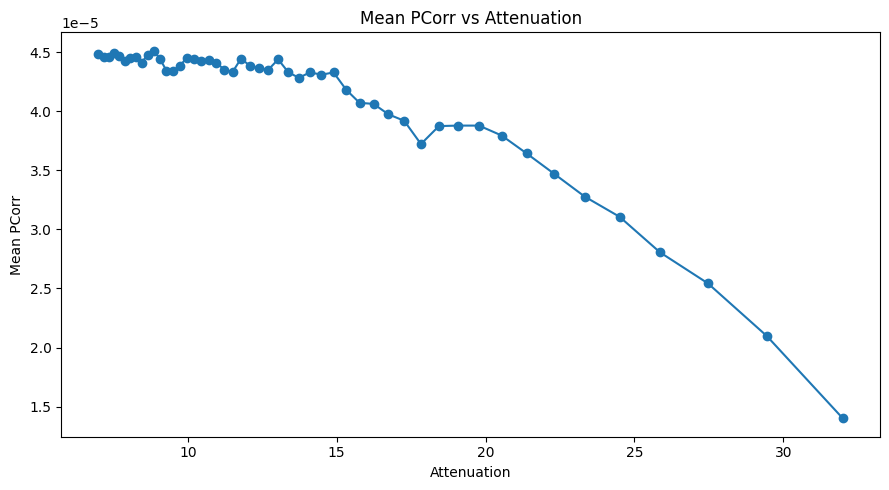

Saved: figures\fig20_mean_pcorr_vs_ampif.png


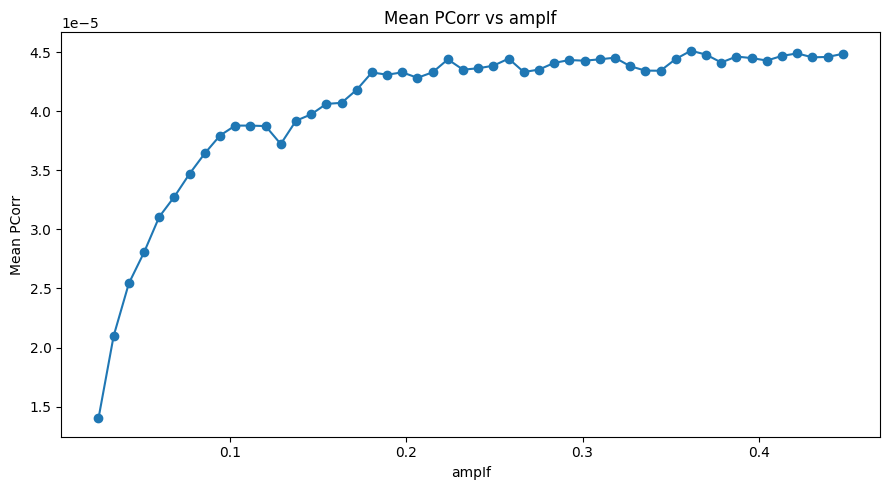


Done. All figures are shown and saved in the 'figures' folder.


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Create figure folder
# =========================
FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)

# =========================
# Load data
# Run notebook from same folder
# =========================
metadata = pd.read_csv("RabiOscillations_metadata.csv")
axes_df = pd.read_csv("RabiOscillations_axes.csv")
pulse_df = pd.read_csv("RabiOscillations_pulseSigmas.csv")
df = pd.read_csv("RabiOscillations_long_dataframe.csv")

print("Loaded files:")
print("metadata:", metadata.shape)
print("axes_df:", axes_df.shape)
print("pulse_df:", pulse_df.shape)
print("long df:", df.shape)

print("\nMetadata:")
display(metadata)

print("\nAxes preview:")
display(axes_df.head())

print("\nPulse sigma preview:")
display(pulse_df.head())

print("\nLong dataframe preview:")
display(df.head())


# =========================
# Extract useful arrays
# =========================
pulse_sigmas = np.sort(df["pulseSigma_s"].unique())
attenuation = np.sort(df["attenuation"].unique())

print("\nUnique pulse sigma count:", len(pulse_sigmas))
print("Unique attenuation count:", len(attenuation))

# pivot tables
pcorr_pivot = df.pivot(index="pulseSigma_s", columns="attenuation", values="PCorr").sort_index()
p1_pivot = df.pivot(index="pulseSigma_s", columns="attenuation", values="P1").sort_index()
p2_pivot = df.pivot(index="pulseSigma_s", columns="attenuation", values="P2").sort_index()
i1_pivot = df.pivot(index="pulseSigma_s", columns="attenuation", values="I1").sort_index()
q1_pivot = df.pivot(index="pulseSigma_s", columns="attenuation", values="Q1").sort_index()
i2_pivot = df.pivot(index="pulseSigma_s", columns="attenuation", values="I2").sort_index()
q2_pivot = df.pivot(index="pulseSigma_s", columns="attenuation", values="Q2").sort_index()
std_pcorr_pivot = df.pivot(index="pulseSigma_s", columns="attenuation", values="STD_PCorr").sort_index()

pcorr_arr = pcorr_pivot.to_numpy(dtype=float)
p1_arr = p1_pivot.to_numpy(dtype=float)
p2_arr = p2_pivot.to_numpy(dtype=float)
i1_arr = i1_pivot.to_numpy(dtype=float)
q1_arr = q1_pivot.to_numpy(dtype=float)
i2_arr = i2_pivot.to_numpy(dtype=float)
q2_arr = q2_pivot.to_numpy(dtype=float)
std_pcorr_arr = std_pcorr_pivot.to_numpy(dtype=float)

pulse_axis = pcorr_pivot.index.to_numpy(dtype=float)
att_axis = pcorr_pivot.columns.to_numpy(dtype=float)

# ampIf map from axes_df
ampif_map = dict(zip(axes_df["attenuation"], axes_df["ampIf"]))
df["ampIf_mapped"] = df["attenuation"].map(ampif_map)

print("\nPivot shape:", pcorr_arr.shape)


# =========================
# Helper function
# =========================
def save_and_show(fig_name):
    plt.tight_layout()
    save_path = os.path.join(FIG_DIR, fig_name)
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    print(f"Saved: {save_path}")
    plt.show()
    plt.close()


# =========================
# Best operating point
# =========================
best_idx = np.unravel_index(np.nanargmax(pcorr_arr), pcorr_arr.shape)
best_pulse = pulse_axis[best_idx[0]]
best_att = att_axis[best_idx[1]]
best_pcorr = pcorr_arr[best_idx]
best_row = df[(df["pulseSigma_s"] == best_pulse) & (df["attenuation"] == best_att)].iloc[0]

print("\nBest operating point based on PCorr:")
print(f"pulseSigma_s = {best_pulse:.6e} s")
print(f"attenuation = {best_att}")
print(f"ampIf = {best_row['ampIf']}")
print(f"PCorr = {best_pcorr}")
print(f"STD_PCorr = {best_row['STD_PCorr']}")


# =========================
# Figure 1: PCorr heatmap
# =========================
plt.figure(figsize=(8, 6))
plt.imshow(
    pcorr_arr,
    aspect="auto",
    extent=[att_axis.min(), att_axis.max(), pulse_axis.min(), pulse_axis.max()],
    origin="lower"
)
plt.xlabel("Attenuation")
plt.ylabel("Pulse Sigma (s)")
plt.title("PCorr Heatmap")
plt.colorbar(label="PCorr")
save_and_show("fig1_pcorr_heatmap.png")


# =========================
# Figure 2: P1 heatmap
# =========================
plt.figure(figsize=(8, 6))
plt.imshow(
    p1_arr,
    aspect="auto",
    extent=[att_axis.min(), att_axis.max(), pulse_axis.min(), pulse_axis.max()],
    origin="lower"
)
plt.xlabel("Attenuation")
plt.ylabel("Pulse Sigma (s)")
plt.title("P1 Heatmap")
plt.colorbar(label="P1")
save_and_show("fig2_p1_heatmap.png")


# =========================
# Figure 3: P2 heatmap
# =========================
plt.figure(figsize=(8, 6))
plt.imshow(
    p2_arr,
    aspect="auto",
    extent=[att_axis.min(), att_axis.max(), pulse_axis.min(), pulse_axis.max()],
    origin="lower"
)
plt.xlabel("Attenuation")
plt.ylabel("Pulse Sigma (s)")
plt.title("P2 Heatmap")
plt.colorbar(label="P2")
save_and_show("fig3_p2_heatmap.png")


# =========================
# Figure 4: I1 heatmap
# =========================
plt.figure(figsize=(8, 6))
plt.imshow(
    i1_arr,
    aspect="auto",
    extent=[att_axis.min(), att_axis.max(), pulse_axis.min(), pulse_axis.max()],
    origin="lower"
)
plt.xlabel("Attenuation")
plt.ylabel("Pulse Sigma (s)")
plt.title("I1 Heatmap")
plt.colorbar(label="I1")
save_and_show("fig4_i1_heatmap.png")


# =========================
# Figure 5: Q1 heatmap
# =========================
plt.figure(figsize=(8, 6))
plt.imshow(
    q1_arr,
    aspect="auto",
    extent=[att_axis.min(), att_axis.max(), pulse_axis.min(), pulse_axis.max()],
    origin="lower"
)
plt.xlabel("Attenuation")
plt.ylabel("Pulse Sigma (s)")
plt.title("Q1 Heatmap")
plt.colorbar(label="Q1")
save_and_show("fig5_q1_heatmap.png")


# =========================
# Figure 6: I2 heatmap
# =========================
plt.figure(figsize=(8, 6))
plt.imshow(
    i2_arr,
    aspect="auto",
    extent=[att_axis.min(), att_axis.max(), pulse_axis.min(), pulse_axis.max()],
    origin="lower"
)
plt.xlabel("Attenuation")
plt.ylabel("Pulse Sigma (s)")
plt.title("I2 Heatmap")
plt.colorbar(label="I2")
save_and_show("fig6_i2_heatmap.png")


# =========================
# Figure 7: Q2 heatmap
# =========================
plt.figure(figsize=(8, 6))
plt.imshow(
    q2_arr,
    aspect="auto",
    extent=[att_axis.min(), att_axis.max(), pulse_axis.min(), pulse_axis.max()],
    origin="lower"
)
plt.xlabel("Attenuation")
plt.ylabel("Pulse Sigma (s)")
plt.title("Q2 Heatmap")
plt.colorbar(label="Q2")
save_and_show("fig7_q2_heatmap.png")


# =========================
# Figure 8: STD_PCorr heatmap
# =========================
plt.figure(figsize=(8, 6))
plt.imshow(
    std_pcorr_arr,
    aspect="auto",
    extent=[att_axis.min(), att_axis.max(), pulse_axis.min(), pulse_axis.max()],
    origin="lower"
)
plt.xlabel("Attenuation")
plt.ylabel("Pulse Sigma (s)")
plt.title("STD_PCorr Heatmap")
plt.colorbar(label="STD_PCorr")
save_and_show("fig8_std_pcorr_heatmap.png")


# =========================
# Figure 9: Best PCorr vs pulse sigma
# =========================
best_pcorr_vs_sigma = df.groupby("pulseSigma_s")["PCorr"].max().reset_index()

plt.figure(figsize=(9, 5))
plt.plot(best_pcorr_vs_sigma["pulseSigma_s"], best_pcorr_vs_sigma["PCorr"], marker="o")
plt.xlabel("Pulse Sigma (s)")
plt.ylabel("Best PCorr")
plt.title("Best PCorr vs Pulse Sigma")
save_and_show("fig9_best_pcorr_vs_pulsesigma.png")


# =========================
# Figure 10: Best attenuation vs pulse sigma
# =========================
idx = df.groupby("pulseSigma_s")["PCorr"].idxmax()
best_curve_df = df.loc[idx, ["pulseSigma_s", "attenuation", "ampIf", "PCorr", "STD_PCorr"]].sort_values("pulseSigma_s")

plt.figure(figsize=(9, 5))
plt.plot(best_curve_df["pulseSigma_s"], best_curve_df["attenuation"], marker="o")
plt.xlabel("Pulse Sigma (s)")
plt.ylabel("Best Attenuation")
plt.title("Best Attenuation vs Pulse Sigma")
save_and_show("fig10_best_attenuation_vs_pulsesigma.png")


# =========================
# Figure 11: Best ampIf vs pulse sigma
# =========================
plt.figure(figsize=(9, 5))
plt.plot(best_curve_df["pulseSigma_s"], best_curve_df["ampIf"], marker="o")
plt.xlabel("Pulse Sigma (s)")
plt.ylabel("Best ampIf")
plt.title("Best ampIf vs Pulse Sigma")
save_and_show("fig11_best_ampif_vs_pulsesigma.png")


# =========================
# Figure 12: PCorr line cuts at selected pulse sigmas
# =========================
selected_sigma_indices = [0, len(pulse_axis)//4, len(pulse_axis)//2, 3*len(pulse_axis)//4, len(pulse_axis)-1]

plt.figure(figsize=(10, 6))
for idx in selected_sigma_indices:
    sigma = pulse_axis[idx]
    subset = df[df["pulseSigma_s"] == sigma].sort_values("attenuation")
    plt.plot(subset["attenuation"], subset["PCorr"], marker="o", label=f"{sigma:.2e} s")

plt.xlabel("Attenuation")
plt.ylabel("PCorr")
plt.title("PCorr vs Attenuation at Selected Pulse Sigmas")
plt.legend()
save_and_show("fig12_pcorr_linecuts_selected_sigma.png")


# =========================
# Figure 13: PCorr line cuts at selected attenuations
# =========================
selected_att_indices = [0, len(att_axis)//4, len(att_axis)//2, 3*len(att_axis)//4, len(att_axis)-1]

plt.figure(figsize=(10, 6))
for idx in selected_att_indices:
    att = att_axis[idx]
    subset = df[df["attenuation"] == att].sort_values("pulseSigma_s")
    plt.plot(subset["pulseSigma_s"], subset["PCorr"], marker="o", label=f"att={att}")

plt.xlabel("Pulse Sigma (s)")
plt.ylabel("PCorr")
plt.title("PCorr vs Pulse Sigma at Selected Attenuations")
plt.legend()
save_and_show("fig13_pcorr_linecuts_selected_attenuation.png")


# =========================
# Figure 14: PCorr with error bar at best attenuation for each pulse sigma
# =========================
plt.figure(figsize=(10, 6))
plt.errorbar(
    best_curve_df["pulseSigma_s"],
    best_curve_df["PCorr"],
    yerr=best_curve_df["STD_PCorr"],
    fmt="o-",
    capsize=3
)
plt.xlabel("Pulse Sigma (s)")
plt.ylabel("Best PCorr")
plt.title("Best PCorr with STD_PCorr Error Bars")
save_and_show("fig14_best_pcorr_with_errorbars.png")


# =========================
# Figure 15: I1 vs Q1 scatter
# =========================
plt.figure(figsize=(6, 6))
plt.scatter(df["I1"], df["Q1"], s=10, alpha=0.5)
plt.xlabel("I1")
plt.ylabel("Q1")
plt.title("I1 vs Q1 Scatter")
save_and_show("fig15_i1_vs_q1_scatter.png")


# =========================
# Figure 16: I2 vs Q2 scatter
# =========================
plt.figure(figsize=(6, 6))
plt.scatter(df["I2"], df["Q2"], s=10, alpha=0.5)
plt.xlabel("I2")
plt.ylabel("Q2")
plt.title("I2 vs Q2 Scatter")
save_and_show("fig16_i2_vs_q2_scatter.png")


# =========================
# Figure 17: P1 vs P2 scatter
# =========================
plt.figure(figsize=(6, 6))
plt.scatter(df["P1"], df["P2"], s=10, alpha=0.5)
plt.xlabel("P1")
plt.ylabel("P2")
plt.title("P1 vs P2 Scatter")
save_and_show("fig17_p1_vs_p2_scatter.png")


# =========================
# Figure 18: Histograms of PCorr, P1, P2
# =========================
plt.figure(figsize=(10, 5))
plt.hist(df["PCorr"], bins=60, alpha=0.5, label="PCorr")
plt.hist(df["P1"], bins=60, alpha=0.5, label="P1")
plt.hist(df["P2"], bins=60, alpha=0.5, label="P2")
plt.xlabel("Value")
plt.ylabel("Count")
plt.title("Histogram of PCorr, P1, and P2")
plt.legend()
save_and_show("fig18_hist_pcorr_p1_p2.png")


# =========================
# Figure 19: Mean PCorr vs attenuation
# =========================
mean_pcorr_vs_att = df.groupby("attenuation")["PCorr"].mean().reset_index()

plt.figure(figsize=(9, 5))
plt.plot(mean_pcorr_vs_att["attenuation"], mean_pcorr_vs_att["PCorr"], marker="o")
plt.xlabel("Attenuation")
plt.ylabel("Mean PCorr")
plt.title("Mean PCorr vs Attenuation")
save_and_show("fig19_mean_pcorr_vs_attenuation.png")


# =========================
# Figure 20: Mean PCorr vs ampIf
# =========================
mean_pcorr_vs_ampif = df.groupby("ampIf_mapped")["PCorr"].mean().reset_index().sort_values("ampIf_mapped")

plt.figure(figsize=(9, 5))
plt.plot(mean_pcorr_vs_ampif["ampIf_mapped"], mean_pcorr_vs_ampif["PCorr"], marker="o")
plt.xlabel("ampIf")
plt.ylabel("Mean PCorr")
plt.title("Mean PCorr vs ampIf")
save_and_show("fig20_mean_pcorr_vs_ampif.png")


print("\nDone. All figures are shown and saved in the 'figures' folder.")